## Predicting Online Purchase Intention from Web Session Behaviour

### A post-session conversion-driver audit

This project uses the UCI Online Shoppers dataset to audit completed web sessions and identify the behaviours most associated with purchase outcomes.

Each row represents one completed session, and the `Revenue` target shows whether that session ended in a purchase. The aim is to compare buyer and non-buyer sessions, then build a classification model that helps analysts review the behavioural patterns linked with conversion.

The scope fits the structure of the dataset. It contains session behaviour over a one-year period, but no marketing channel, advert, campaign or customer identity fields. For that reason, the project is framed around conversion-driver analysis rather than campaign attribution.

Because the analysis is carried out after the session has finished, end-of-session features can be included. This makes `PageValues` a valid feature for this design, while still needing separate discussion because of how strongly it relates to purchase behaviour.

[1] C. Sakar and Y. Kastro, “Online Shoppers Purchasing Intention Dataset,” UCI Machine Learning Repository, 2018. [Online]. Available: https://doi.org/10.24432/C5F88Q
[2] scikit-learn developers, "LogisticRegression," scikit-learn, 2026. [Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

# Section 1: The Data

## Imports and settings

A fixed `RANDOM_STATE` keeps the split, tuning and resampling reproducible.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.model_selection import RandomizedSearchCV, RepeatedStratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    make_scorer, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)

RANDOM_STATE = 42

## Initial data examination

In [44]:
df = pd.read_csv("../data/online_shoppers_intention.csv")
df.head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


Each row represents a completed web session, with `Revenue` used as the binary purchase target. 

The input features combine browsing activity, such as page counts and durations, with engagement signals such as `BounceRates`, `ExitRates` and `PageValues`. 

The dataset also includes session context, including `Month`, `VisitorType` and `Weekend`, together with coded technical fields such as operating system, browser, region and traffic type.

## Initial inspection

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

The dataset has 12,330 rows, 18 columns, no nulls reported.

The data contains a mixture of types: integers, floats, strings and Boolean values. Categorical and Boolean fields need encoding before modelling.

## Data quality: duplicates

Exact duplicates are inspected before any modelling decisions are made, because repeated rows can distort both class balance and model evaluation.

In [46]:
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(125)

In [47]:
duplicate_rows = df[df.duplicated(keep=False)].copy()

duplicate_rows_summary = pd.DataFrame({
    "duplicate_rows_including_originals": [len(duplicate_rows)],
    "duplicate_groups": [duplicate_rows.groupby(list(df.columns)).ngroups],
    "max_repeated_group_size": [
        duplicate_rows.groupby(list(df.columns)).size().max()
    ],
    "purchase_duplicates": [duplicate_rows["Revenue"].sum()],
    "non_purchase_duplicates": [(duplicate_rows["Revenue"] == False).sum()],
    "max_product_duration_in_duplicates": [
        duplicate_rows["ProductRelated_Duration"].max()
    ]
})

duplicate_rows_summary

,duplicate_rows_including_originals,duplicate_groups,max_repeated_group_size,purchase_duplicates,non_purchase_duplicates,max_product_duration_in_duplicates
0,201,76,14,0,201,0.0


The duplicate check found 201 rows involved in duplication, grouped into 76 repeated session patterns. After keeping one copy of each pattern, this means 125 rows would be removed. The largest repeated pattern appears 14 times.

All duplicated patterns are non-purchase sessions, and their maximum `ProductRelated_Duration` is 0. This suggests repeated empty or very short visits rather than additional behavioural evidence. 

*Design choice: Removing the duplicates will help to avoid strengthening the majority class with repeated non-purchase records, while keeping the modelling dataset focused on distinct session behaviour.*

In [48]:
df = df.drop_duplicates().reset_index(drop=True)

df.shape

(12205, 18)

12,205 sessions remain. No purchase sessions were lost, so the imbalance is now slightly less extreme but still large, which shapes the validation strategy and metric choice later.

## Target imbalance

In [49]:
revenue_summary = pd.DataFrame({
    "count": df["Revenue"].value_counts(),
    "percentage": df["Revenue"].value_counts(normalize=True) * 100
})

revenue_summary

,count,percentage
Revenue,,
False,10297,84.367063
True,1908,15.632937


Only 15.6% of sessions convert to `Revenue` (1,908 of 12,205). This class imbalance means accuracy could be misleading: a model that predicts “no purchase” for every session would still achieve about 84% accuracy, but would identify no buyers.

For this reason, accuracy is treated as a secondary measure. Model selection focuses on purchase-class precision, recall, F1-score and the confusion matrix, because these show how well the model identifies the smaller but more important purchase class.

In [50]:
scale_check = df.describe().loc[["min", "50%", "max", "std"]].T

scale_check = scale_check.rename(columns={"50%": "median"})
scale_check["range"] = scale_check["max"] - scale_check["min"]

scale_check.sort_values("range", ascending=False)

,min,median,max,std,range
ProductRelated_Duration,0.0,608.942857,63973.522230,1919.601400,63973.522230
Administrative_Duration,0.0,9.000000,3398.750000,177.491845,3398.750000
Informational_Duration,0.0,0.000000,2549.375000,141.424807,2549.375000
ProductRelated,0.0,18.000000,705.000000,44.593649,705.000000
PageValues,0.0,0.000000,361.763742,18.653671,361.763742
Administrative,0.0,1.000000,27.000000,3.330436,27.000000
Informational,0.0,0.000000,24.000000,1.275617,24.000000
TrafficType,1.0,2.000000,20.000000,4.016654,19.000000
Browser,1.0,2.000000,13.000000,1.710114,12.000000
Region,1.0,3.000000,9.000000,2.402340,8.000000


The scale check shows why standardisation is needed: `ProductRelated_Duration` reaches almost 64,000 seconds, while `BounceRates` and `ExitRates` stay between 0 and 0.2. Without scaling, models such as KNN, SVM and Logistic Regression could be pulled towards the largest-value features, motivating standardisation inside the pipeline rather than edits to the raw data.

In [51]:
df.sort_values("ProductRelated_Duration", ascending=False).head(10)[
    ["ProductRelated", "ProductRelated_Duration", "PageValues", "BounceRates", "ExitRates", "Revenue"]
]

,ProductRelated,ProductRelated_Duration,PageValues,BounceRates,ExitRates,Revenue
7983,449,63973.52223,0.000000,0.000764,0.027701,False
5074,705,43171.23338,0.763829,0.004851,0.015431,False
9149,343,29970.46597,0.000000,0.005316,0.028971,False
8695,517,27009.85943,8.403164,0.004385,0.014594,True
8220,584,24844.15620,4.511100,0.002099,0.009347,False
7574,414,23888.81000,1.033757,0.009900,0.027062,False
6599,686,23342.08205,0.150650,0.009853,0.022771,False
6080,486,23050.10414,0.000000,0.000324,0.011249,False
5831,439,21857.04648,11.439233,0.003589,0.012498,False
8883,501,21672.24425,9.131387,0.003965,0.014292,True


The longest `ProductRelated_Duration` values (~63,974 seconds, ~17.8 hours) are not duplicates. They carry distinct `ProductRelated`, `PageValues` and `rate` values. These seem to be long or idle-tab sessions, so they are retained rather than treated as errors.

In [52]:
categorical_cols = ["Month", "VisitorType", "Weekend", "OperatingSystems", "Browser", "Region", "TrafficType"]

categorical_summary = pd.DataFrame({
    "unique_values": df[categorical_cols].nunique(),
    "most_common_value": df[categorical_cols].mode().iloc[0],
    "most_common_count": [df[col].value_counts().iloc[0] for col in categorical_cols],
    "most_common_percentage": [
        df[col].value_counts(normalize=True).iloc[0] * 100
        for col in categorical_cols
    ]
})

categorical_summary["most_common_percentage"] = (
    categorical_summary["most_common_percentage"].round(2)
)

categorical_summary

,unique_values,most_common_value,most_common_count,most_common_percentage
Month,10,May,3329,27.28
VisitorType,3,Returning_Visitor,10431,85.46
Weekend,2,False,9346,76.58
OperatingSystems,8,2,6541,53.59
Browser,13,2,7883,64.59
Region,9,1,4714,38.62
TrafficType,20,2,3911,32.04


The categorical and coded fields are unevenly distributed. `Returning_Visitor` accounts for 85.5% of sessions, while `Browser` value 2 and `OperatingSystems` value 2 account for 64.6% and 53.6%. Their integers are labels, not quantities, so they are one-hot encoded. The skew is also worth keeping in mind when interpreting one-hot feature scores later, because rare categories can carry limited evidence.

## Behavioural differences between buyers and non-buyers

In [53]:
df.groupby("Revenue")[["PageValues", "BounceRates", "ExitRates", "ProductRelated", "ProductRelated_Duration"]].mean()

,PageValues,BounceRates,ExitRates,ProductRelated,ProductRelated_Duration
Revenue,,,,,
False,1.999985,0.023197,0.045526,29.050403,1082.976881
True,27.264518,0.005117,0.019555,48.210168,1876.209615


The grouped averages show a clear behavioural difference between purchase and non-purchase sessions. Purchase sessions have much higher average `PageValues` at 27.3 compared with 2.0, along with more product page visits, longer product browsing time and lower bounce and exit rates.

This suggests that browsing depth and page value may be useful predictors. `PageValues` does most of the separating, a point examined critically below before it is trusted.

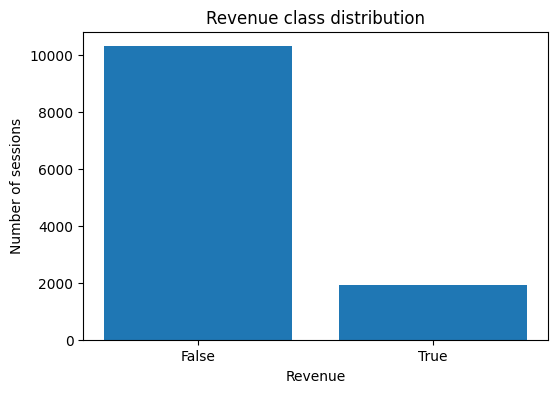

In [54]:
revenue_counts = df["Revenue"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(revenue_counts.index.astype(str), revenue_counts.values)
plt.title("Revenue class distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of sessions")
plt.show()

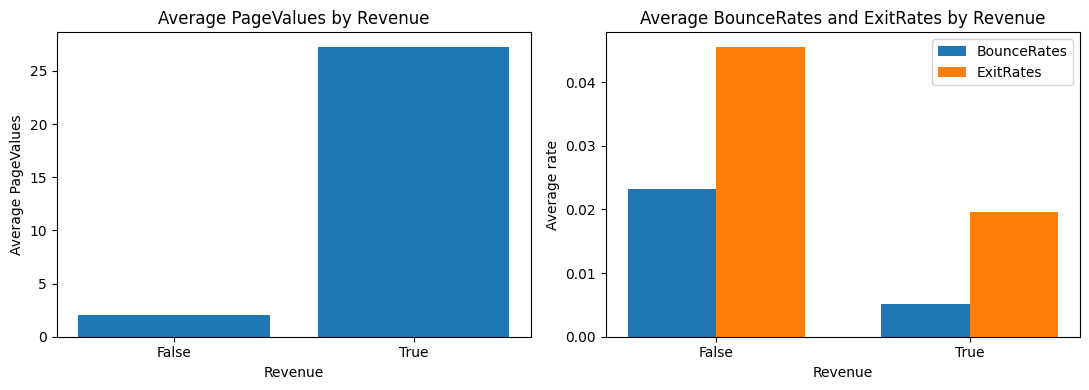

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

pagevalues_mean = df.groupby("Revenue")["PageValues"].mean()
axes[0].bar(pagevalues_mean.index.astype(str), pagevalues_mean.values)
axes[0].set_title("Average PageValues by Revenue")
axes[0].set_xlabel("Revenue")
axes[0].set_ylabel("Average PageValues")

rate_means = df.groupby("Revenue")[["BounceRates", "ExitRates"]].mean()
x = np.arange(len(rate_means.index))
width = 0.35
axes[1].bar(x - width/2, rate_means["BounceRates"], width, label="BounceRates")
axes[1].bar(x + width/2, rate_means["ExitRates"], width, label="ExitRates")
axes[1].set_title("Average BounceRates and ExitRates by Revenue")
axes[1].set_xlabel("Revenue")
axes[1].set_ylabel("Average rate")
axes[1].set_xticks(x)
axes[1].set_xticklabels(rate_means.index.astype(str))
axes[1].legend()

plt.tight_layout()
plt.show()

The charts make the gap clear. Buyers have significantly higher `PageValues` and markedly lower bounce/exit rates. Visitors who stay and move through product pages convert more often, so engagement and exit behaviour are promising signals, therefore these features are carried forward into mutual information and permutation importance feature checks.

### A design note on `PageValues`

`PageValues` is a Google Analytics metric that represents the average value of pages a visitor saw before completing an e-commerce transaction [1]. In this project it is included deliberately, because the model is designed as a post-session audit using completed-session information.

Because `PageValues` is expected to be highly predictive, it is treated as a feature that needs interpretation. The later checks look at both model dependence on `PageValues` and the added value of wider behaviour signals such as `ExitRates`, `ProductRelated`, `BounceRates` and session timing.

## Preprocessing plan

The preprocessing is kept inside the modelling pipeline so each transform is fitted only on the training data used in that fold. This is the main leakage-control step.

Continuous numeric features are standardised because the duration variables are much larger than the rate features, which matters for `KNN`, `SVM` and `Logistic Regression`. The same preprocessing structure is used across models for consistency, even though tree-based models are not sensitive to feature scale. Categorical fields are one-hot encoded because values such as `Month`, `VisitorType`, `Browser` and `TrafficType` are labels rather than numeric measurements.

# Section 2: Constructing and Selecting Features

## Feature and target split

In [56]:
# Separate the input features from the target variable
X_original = df.drop(columns=["Revenue"])
y = df["Revenue"]

print("Feature data shape:", X_original.shape)
print("Target data shape:", y.shape)

Feature data shape: (12205, 17)
Target data shape: (12205,)


In [57]:
categorical_features = [
    "Month",
    "VisitorType",
    "Weekend",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]

numerical_features_original = [
    col for col in X_original.columns
    if col not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features_original)

Categorical features:
['Month', 'VisitorType', 'Weekend', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Numerical features:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']


The columns are separated into categorical and numerical features before preprocessing. The UCI description groups the dataset into 10 numerical attributes and 8 categorical attributes [1]. `Weekend` is included with the categorical features because it describes the session type rather than a measured quantity. `OperatingSystems`, `Browser`, `Region` and `TrafficType` are also treated as categorical because their values are coded labels, not numbers with a meaningful order. The remaining ten fields are treated as numerical browsing-behaviour features, including page counts, page durations, Google Analytics rates, `PageValues` and `SpecialDay`.

In [58]:
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(
    X_original,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training features:", X_train_original.shape)
print("Test features:", X_test_original.shape)
print("Training target:", y_train_original.shape)
print("Test target:", y_test_original.shape)

Training features: (9764, 17)
Test features: (2441, 17)
Training target: (9764,)
Test target: (2441,)


An 80/20 train-test split is used with `stratify=y`, keeping the 15.6% purchase rate consistent across both sets. This gives the models enough data to learn from, while keeping a held-out test set that reflects the original class balance. The test set is kept back until final evaluation.

In [59]:
split_balance = pd.DataFrame({
    "train_percentage": y_train_original.value_counts(normalize=True) * 100,
    "test_percentage": y_test_original.value_counts(normalize=True) * 100
})

split_balance

,train_percentage,test_percentage
Revenue,,
False,84.371159,84.350676
True,15.628841,15.649324


In [60]:
preprocessor_original = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features_original),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ],
    sparse_threshold=0
)

print(preprocessor_original)

ColumnTransformer(sparse_threshold=0,
                  transformers=[('num', StandardScaler(),
                                 ['Administrative', 'Administrative_Duration',
                                  'Informational', 'Informational_Duration',
                                  'ProductRelated', 'ProductRelated_Duration',
                                  'BounceRates', 'ExitRates', 'PageValues',
                                  'SpecialDay']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Month', 'VisitorType', 'Weekend',
                                  'OperatingSystems', 'Browser', 'Region',
                                  'TrafficType'])])


The original-feature preprocessor standardises the ten numerical columns and one-hot encodes the seven categorical columns. This gives every classifier the same all-numeric input while keeping the preprocessing logic in one shared pipeline.

## Filter-based feature selection: mutual information

Mutual information is computed on the training data only, so feature analysis never sees the test set. The aim is to map the strongest individual signals before modelling.

In [61]:
mi_preprocessor = clone(preprocessor_original)

X_train_processed = mi_preprocessor.fit_transform(X_train_original)
processed_feature_names = mi_preprocessor.get_feature_names_out()

mi_scores = mutual_info_classif(
    X_train_processed,
    y_train_original,
    random_state=RANDOM_STATE
)

mi_scores_df = (
    pd.DataFrame({"feature": processed_feature_names, "mutual_information": mi_scores})
    .sort_values(by="mutual_information", ascending=False)
    .reset_index(drop=True)
)

mi_scores_display_df = mi_scores_df.copy()
mi_scores_display_df["feature"] = (
    mi_scores_display_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

mi_scores_display_df.head(15)

,feature,mutual_information
0,PageValues,0.163820
1,ExitRates,0.037809
2,ProductRelated_Duration,0.032262
3,BounceRates,0.020914
4,ProductRelated,0.019765
5,Administrative,0.017184
6,Month_Nov,0.013419
7,SpecialDay,0.009886
8,TrafficType_15,0.009080
9,Administrative_Duration,0.008649


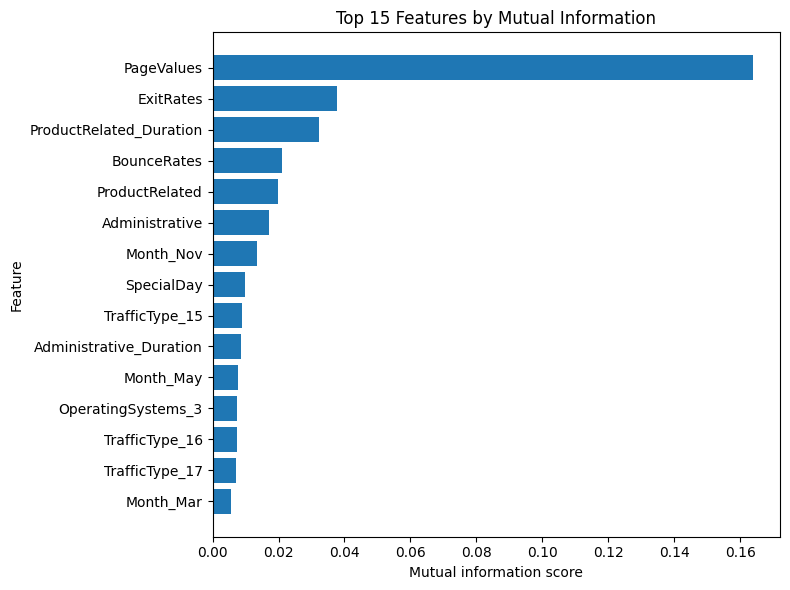

In [62]:
top_mi_features = mi_scores_display_df.head(15).sort_values("mutual_information")

plt.figure(figsize=(8, 6))
plt.barh(top_mi_features["feature"], top_mi_features["mutual_information"])
plt.xlabel("Mutual information score")
plt.ylabel("Feature")
plt.title("Top 15 Features by Mutual Information")
plt.tight_layout()
plt.show()

`PageValues` leads at 0.164, roughly four times the next feature. The rest of the top features are session-quality signals: `ExitRates` at 0.038, `ProductRelated_Duration` at 0.032, `BounceRates` at 0.021 and `ProductRelated` at 0.020.

One caveat is that mutual information is scored per one-hot column, so a multi-level field like `Month` is split across dummy variables and its overall signal may be understated here. This is checked later with model-based importance.

### SelectKBest and the feature-selection decision

`SelectKBest` applies the mutual information ranking as a formal filter-based feature selection step. It confirms which features would be retained under a top-k selection rule.

The final models still use the full feature set because lower-ranked variables may add value in combination with stronger predictors. Therefore, this step is used for feature analysis and interpretation rather than permanent feature removal.

In [63]:
TOP_K_FEATURES = 5

def reproducible_mutual_info(X, y):
    return mutual_info_classif(
        X,
        y,
        random_state=RANDOM_STATE
    )

selected_feature_selector = SelectKBest(
    score_func=reproducible_mutual_info,
    k=TOP_K_FEATURES
)

selected_feature_selector.fit(X_train_processed, y_train_original)

selected_features_df = (
    pd.DataFrame({
        "selected_feature": processed_feature_names[selected_feature_selector.get_support()],
        "mutual_information": selected_feature_selector.scores_[selected_feature_selector.get_support()]
    })
    .sort_values(by="mutual_information", ascending=False)
    .reset_index(drop=True)
)

selected_features_df

,selected_feature,mutual_information
0,num__PageValues,0.163820
1,num__ExitRates,0.037809
2,num__ProductRelated_Duration,0.032262
3,num__BounceRates,0.020914
4,num__ProductRelated,0.019765


The selected features are all linked to completed-session behaviour. `PageValues` is the dominant feature, while `ExitRates`, `BounceRates`, `ProductRelated` and `ProductRelated_Duration` provide weaker but still relevant browsing-behaviour signals.

SelectKBest turns the mutual-information ranking into a formal top-k filter. With k = 5 it keeps PageValues, ExitRates, ProductRelated_Duration, BounceRates and ProductRelated, all of which are completed-session behaviour.

No features are dropped here. Mutual information scores each feature on its own, so lower-ranked features may still help when combined with others. Contextual fields such as `Month`, `VisitorType`, `TrafficType` and `Weekend` are also kept for possible seasonal or visitor pattern effects.

Whether a reduced set actually preserves performance is a model-level question, so it is tested in Section 3 once candidate models exist. At this point, the main takeaway is that the strongest individual signals are session activity features, which is where the later feature-engineering cycle focuses.

# Section 3: Building ML Algorithms

This is a supervised binary classification task because each session has a known `Revenue` label.

Eight classifiers span the main families so the comparison is not tied to one assumption: linear (`Logistic Regression`), kernel (`Support Vector Machine`), instance-based (`K-Nearest Neighbours`), single-tree (`Decision Tree`), bagged and boosted ensembles (`Random Forest`, `Gradient Boosting`, `Hist Gradient Boosting`) and a neural network (`MLPClassifier`).

## 3.1 Baseline comparison: controlled algorithm comparison

The baseline models are run without class weighting so the first comparison uses the same basic setup for every classifier. This keeps the screen focused on the algorithms themselves, rather than mixing algorithm performance with different imbalance-handling options. Class imbalance is still accounted for through the evaluation metrics, then handled more directly during tuning.

A shared evaluation helper reports the confusion matrix and purchase-class precision, recall and F1-score for every model.

In [64]:
def evaluate_model(model_name, model, X_test, y_test):
    
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label=True, zero_division=0),
        "recall": recall_score(y_test, y_pred, pos_label=True, zero_division=0),
        "f1": f1_score(y_test, y_pred, pos_label=True, zero_division=0)
    }
    
    print("\n" + model_name)
    print("Confusion matrix:")
    print(cm)
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    return results, y_pred, cm

In [65]:
# Baseline models: no class weighting, so the screen is like-for-like across families.
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "K-Nearest Neighbours": KNeighborsClassifier(),
    "Support Vector Machine": SVC(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    "MLPClassifier": MLPClassifier(max_iter=500, random_state=RANDOM_STATE)
}

In [66]:
baseline_results = []
trained_pipelines = {}
baseline_predictions = {}
baseline_confusion_matrices = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", clone(preprocessor_original)),
        ("model", clone(model))
    ])

    pipeline.fit(X_train_original, y_train_original)

    results, y_pred, cm = evaluate_model(
        model_name,
        pipeline,
        X_test_original,
        y_test_original
    )

    baseline_results.append(results)
    trained_pipelines[model_name] = pipeline
    baseline_predictions[model_name] = y_pred
    baseline_confusion_matrices[model_name] = cm



Logistic Regression
Confusion matrix:
[[2007   52]
 [ 224  158]]

Classification report:
              precision    recall  f1-score   support

       False       0.90      0.97      0.94      2059
        True       0.75      0.41      0.53       382

    accuracy                           0.89      2441
   macro avg       0.83      0.69      0.73      2441
weighted avg       0.88      0.89      0.87      2441


Decision Tree
Confusion matrix:
[[1875  184]
 [ 166  216]]

Classification report:
              precision    recall  f1-score   support

       False       0.92      0.91      0.91      2059
        True       0.54      0.57      0.55       382

    accuracy                           0.86      2441
   macro avg       0.73      0.74      0.73      2441
weighted avg       0.86      0.86      0.86      2441


Random Forest
Confusion matrix:
[[1994   65]
 [ 170  212]]

Classification report:
              precision    recall  f1-score   support

       False       0.92      0.97

/Users/garyzolty/Desktop/University/AML/aml-online-shoppers/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [67]:
baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
6,Hist Gradient Boosting,0.904957,0.727273,0.628272,0.674157
5,Gradient Boosting,0.901680,0.708824,0.630890,0.667590
2,Random Forest,0.903728,0.765343,0.554974,0.643399
4,Support Vector Machine,0.895535,0.736059,0.518325,0.608295
7,MLPClassifier,0.878329,0.617729,0.583770,0.600269
1,Decision Tree,0.856616,0.540000,0.565445,0.552430
0,Logistic Regression,0.886932,0.752381,0.413613,0.533784
3,K-Nearest Neighbours,0.873413,0.662222,0.390052,0.490939


On the unweighted baseline screen, the boosting models lead on purchase-class F1, the score used here to balance how many buyers are found with how many purchase predictions are correct. `Hist Gradient Boosting` scores 0.674 and `Gradient Boosting` scores 0.668.

The precision and recall split shows why tuning is needed. `Random Forest` has strong precision but lower recall at P 0.765 / R 0.555, while `Logistic Regression` at P 0.752 / R 0.414 and `SVM` at P 0.736 / R 0.518 are even more cautious. They make relatively accurate purchase predictions when they do predict purchase, but miss many actual buyers. This is the gap that class weighting targets during tuning.

`Gradient Boosting`, `Hist Gradient Boosting`, `Random Forest`, `SVM`, `Logistic Regression` and `MLPClassifier` are carried forward for tuning. `MLPClassifier` is included as a different model family, with tuning used to address the convergence warning from the baseline run.

## 3.2 Exploratory model-based importance

Gradient Boosting gives a quick model-side view of feature importance before tuning. This is exploratory, because built-in importance is model-specific and one-hot encoded fields are split across separate dummy columns.

In [68]:
gb_pipeline = trained_pipelines["Gradient Boosting"]

gb_model = gb_pipeline.named_steps["model"]
gb_preprocessor = gb_pipeline.named_steps["preprocessor"]
feature_names = gb_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": gb_model.feature_importances_
})

feature_importance.sort_values(by="importance", ascending=False).head(10)

,feature,importance
8,num__PageValues,0.746017
17,cat__Month_Nov,0.044649
6,num__BounceRates,0.043008
5,num__ProductRelated_Duration,0.034506
0,num__Administrative,0.030777
7,num__ExitRates,0.025386
1,num__Administrative_Duration,0.014230
4,num__ProductRelated,0.013252
16,cat__Month_May,0.008298
22,cat__VisitorType_Returning_Visitor,0.006751


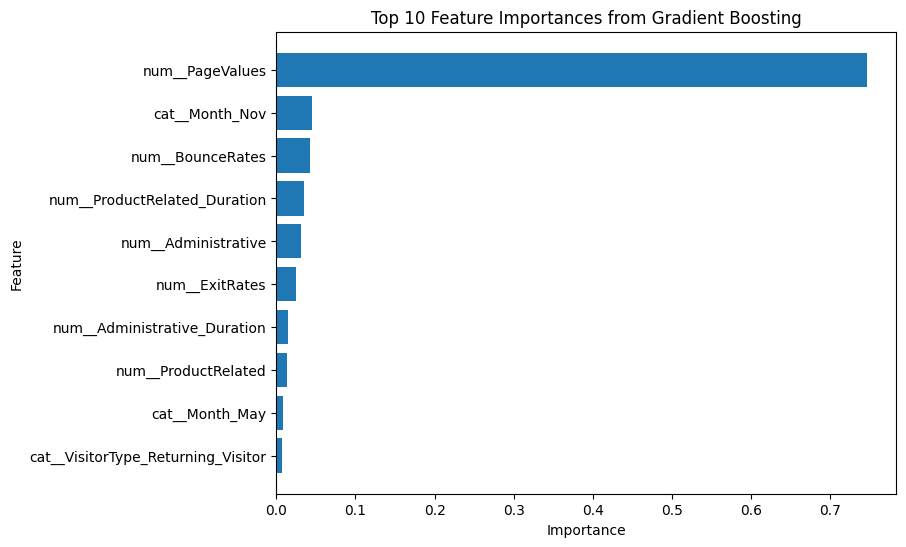

In [69]:
top_features = feature_importance.sort_values(by="importance", ascending=False).head(10)

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.title("Top 10 Feature Importances from Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

`PageValues` dominates again, but the next features add useful context. `Month_Nov`, `BounceRates`, `ProductRelated_Duration`, `Administrative` and `ExitRates` all appear in the top group. The presence of `Month_Nov` and `Month_May` suggests that the original `Month` field may carry more signal than the mutual-information chart showed, because its effect is divided across individual month columns. This is checked later with permutation importance on the final contenders.

### Diagnostic: how much does the model lean on `PageValues`?

This check tests the `PageValues` design issue directly: the same `Gradient Boosting` model is cross-validated on the training data once with `PageValues` and once without it.

In [70]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

X_train_with_pagevalues = X_train_original.copy()
X_train_without_pagevalues = X_train_original.drop(columns=["PageValues"])

numerical_features_without_pagevalues = [
    col for col in numerical_features_original
    if col != "PageValues"
]

preprocessor_with_pagevalues = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features_original),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

preprocessor_without_pagevalues = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features_without_pagevalues),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Same model used in both experiments
gb_with_pagevalues_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_with_pagevalues),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

gb_without_pagevalues_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_without_pagevalues),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

cv_with_pagevalues = cross_validate(
    gb_with_pagevalues_pipeline,
    X_train_with_pagevalues,
    y_train_original,
    cv=cv,
    scoring=scoring
)

cv_without_pagevalues = cross_validate(
    gb_without_pagevalues_pipeline,
    X_train_without_pagevalues,
    y_train_original,
    cv=cv,
    scoring=scoring
)

pagevalues_cv_comparison = pd.DataFrame({
    "With PageValues": [
        cv_with_pagevalues["test_accuracy"].mean(),
        cv_with_pagevalues["test_precision"].mean(),
        cv_with_pagevalues["test_recall"].mean(),
        cv_with_pagevalues["test_f1"].mean()
    ],
    "Without PageValues": [
        cv_without_pagevalues["test_accuracy"].mean(),
        cv_without_pagevalues["test_precision"].mean(),
        cv_without_pagevalues["test_recall"].mean(),
        cv_without_pagevalues["test_f1"].mean()
    ]
}, index=["accuracy", "precision", "recall", "f1"])

pagevalues_cv_comparison["Difference"] = (
    pagevalues_cv_comparison["Without PageValues"]
    - pagevalues_cv_comparison["With PageValues"]
)

pagevalues_cv_comparison

,With PageValues,Without PageValues,Difference
accuracy,0.902192,0.845862,-0.056330
precision,0.728340,0.550415,-0.177925
recall,0.597634,0.079310,-0.518324
f1,0.656280,0.138221,-0.518059


Removing `PageValues` changes the model completely. F1 falls from 0.656 to 0.138, and recall falls from 0.598 to 0.079, while accuracy only drops by 0.056. This shows why accuracy is not enough for this task: the model can still classify most non-purchase sessions correctly, but almost stop finding buyers.

`PageValues` is kept because it fits the post-session design. The session has already finished, so the analyst can use the value of pages visited before a transaction as part of the review. The key point is not only that `PageValues` improves performance, but how strongly the model relies on it. The next step checks whether other behaviour signals, such as `ExitRates`, `BounceRates`, `ProductRelated` and session timing, still add value.

## 3.3 Original-feature tuning

The strongest baseline candidates are tuned with `RandomizedSearchCV`, five-fold cross-validation and `scoring="f1"`, because F1 balances how many buyers are found with how many purchase predictions are correct. Random search is used instead of grid search because it allows a wider range of parameter values to be tested within the same compute budget.

Class imbalance is handled during tuning by testing `class_weight="balanced"` where the model supports it, alongside the other hyperparameters.

### Tuning Gradient Boosting

In [71]:
gb_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor_original)),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

gb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__min_samples_leaf": [1, 2]
}

gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=gb_param_grid,
    n_iter=6,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
gb_search.fit(X_train_original, y_train_original)

print("Best parameters:")
print(gb_search.best_params_)

print("Best cross-validation F1-score:")
print(gb_search.best_score_)

Best parameters:
{'model__n_estimators': 200, 'model__min_samples_leaf': 1, 'model__max_depth': 3, 'model__learning_rate': 0.05}
Best cross-validation F1-score:
0.6603656495665394


In [72]:
# Initialise the tuned results list once
tuned_results = []

gb_tuned_results, gb_tuned_pred, gb_tuned_confusion = evaluate_model(
    "Tuned Gradient Boosting", gb_search, X_test_original, y_test_original
)
tuned_results.append(gb_tuned_results)
gb_tuned_results


Tuned Gradient Boosting
Confusion matrix:
[[1964   95]
 [ 139  243]]

Classification report:
              precision    recall  f1-score   support

       False       0.93      0.95      0.94      2059
        True       0.72      0.64      0.68       382

    accuracy                           0.90      2441
   macro avg       0.83      0.79      0.81      2441
weighted avg       0.90      0.90      0.90      2441



{'model': 'Tuned Gradient Boosting',
 'accuracy': 0.9041376485047112,
 'precision': 0.7189349112426036,
 'recall': 0.6361256544502618,
 'f1': 0.675}

`Tuned Gradient Boosting` improves slightly over baseline, moving from F1 `0.668` to `0.675` with `200` boosting stages, `max_depth=3` and `learning_rate=0.05`. It is ruled in as a precision-leaning contender.

### Tuning Hist Gradient Boosting

In [112]:
hgb_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor_original)),
    ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))
])

hgb_param_grid = {
    "model__max_iter": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_leaf_nodes": [15, 31],
    "model__l2_regularization": [0, 0.1]
}

hgb_search = RandomizedSearchCV(
    estimator=hgb_pipeline,
    param_distributions=hgb_param_grid,
    n_iter=6,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
hgb_search.fit(X_train_original, y_train_original)

print("Best parameters:")
print(hgb_search.best_params_)

print("Best cross-validation F1-score:")
print(hgb_search.best_score_)

hgb_tuned_results, hgb_tuned_pred, hgb_tuned_confusion = evaluate_model(
    "Tuned Hist Gradient Boosting", hgb_search, X_test_original, y_test_original
)
tuned_results.append(hgb_tuned_results)

Best parameters:
{'model__max_leaf_nodes': 15, 'model__max_iter': 100, 'model__learning_rate': 0.05, 'model__l2_regularization': 0}
Best cross-validation F1-score:
0.6520259415075544

Tuned Hist Gradient Boosting
Confusion matrix:
[[1966   93]
 [ 144  238]]

Classification report:
              precision    recall  f1-score   support

       False       0.93      0.95      0.94      2059
        True       0.72      0.62      0.67       382

    accuracy                           0.90      2441
   macro avg       0.83      0.79      0.81      2441
weighted avg       0.90      0.90      0.90      2441



`Tuned Hist Gradient Boosting` drops slightly against baseline, moving from F1 `0.674` to `0.668` with `max_leaf_nodes=15`, `max_iter=100` and `learning_rate=0.05`. It is ruled out as the lead boosting model, but kept in the comparison table.

### Tuning Support Vector Machine

In [ ]:
svm_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor_original)),
    ("model", SVC(random_state=RANDOM_STATE))
])

svm_param_grid = [
    {
        "model__kernel": ["linear"],
        "model__C": [0.1, 1, 10, 50],
        "model__class_weight": ["balanced", None]
    },
    {
        "model__kernel": ["rbf"],
        "model__C": [0.1, 1, 10, 50],
        "model__gamma": ["scale", 0.01, 0.1, 1],
        "model__class_weight": ["balanced", None]
    }
]

svm_search = RandomizedSearchCV(
    estimator=svm_pipeline,
    param_distributions=svm_param_grid,
    n_iter=12,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

svm_search.fit(X_train_original, y_train_original)

print("Best parameters:")
print(svm_search.best_params_)
print("\nBest CV F1-score:")
print(svm_search.best_score_)

svm_tuned_results, svm_tuned_pred, svm_tuned_confusion = evaluate_model(
    "Tuned Support Vector Machine", svm_search, X_test_original, y_test_original
)
tuned_results.append(svm_tuned_results)

Best parameters:
{'model__kernel': 'rbf', 'model__gamma': 0.01, 'model__class_weight': 'balanced', 'model__C': 10}

Best CV F1-score:
0.6535302362227585

Tuned Support Vector Machine
Confusion matrix:
[[1833  226]
 [  86  296]]

Classification report:
              precision    recall  f1-score   support

       False       0.96      0.89      0.92      2059
        True       0.57      0.77      0.65       382

    accuracy                           0.87      2441
   macro avg       0.76      0.83      0.79      2441
weighted avg       0.89      0.87      0.88      2441



`Tuned Support Vector Machine` improves over baseline, moving from F1 `0.608` to `0.653` with `kernel='rbf'`, `C=10`, `gamma=0.01` and `class_weight='balanced'`. It is ruled out as the main model because recall is strong at `0.77`, but precision stays lower at `0.57`.

### Tuning Logistic Regression

`Logistic Regression` is tuned as the main interpretable linear comparison model. The search compares different regularisation strengths using `C`, and compares `l1_ratio=0` and `l1_ratio=1`.

`l1_ratio=0` represents L2 regularisation and `l1_ratio=1` represents L1 regularisation. This allows the linear model to compare two common regularisation approaches while keeping the tuning search small and focused.

In [ ]:
# scikit-learn 1.8+ uses l1_ratio instead of the deprecated penalty argument [2].
# l1_ratio controls the regularisation mix: 0 = L2, 1 = L1, between 0 and 1 = Elastic Net.
# solver='saga' is used because it supports this full regularisation range.
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor_original)),
    ("model", LogisticRegression(
        solver="saga",
        l1_ratio=0.0,
        C=1.0,
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

logreg_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 50],
    "model__l1_ratio": [0.0, 0.5, 1.0]
}

logreg_search = RandomizedSearchCV(
    logreg_pipeline, 
    logreg_param_grid, 
    n_iter=8, 
    scoring="f1", 
    cv=5, 
    random_state=RANDOM_STATE, 
    n_jobs=-1
)
logreg_search.fit(X_train_original, y_train_original)

print("Best parameters:", logreg_search.best_params_)
print("Best CV F1-score:", logreg_search.best_score_)

logreg_tuned_results, logreg_tuned_pred, logreg_tuned_confusion = evaluate_model(
    "Tuned Logistic Regression", logreg_search, X_test_original, y_test_original
)
tuned_results.append(logreg_tuned_results)

Best parameters: {'model__l1_ratio': 1.0, 'model__C': 0.01}
Best CV F1-score: 0.6501451283025184

Tuned Logistic Regression
Confusion matrix:
[[1853  206]
 [  94  288]]

Classification report:
              precision    recall  f1-score   support

       False       0.95      0.90      0.93      2059
        True       0.58      0.75      0.66       382

    accuracy                           0.88      2441
   macro avg       0.77      0.83      0.79      2441
weighted avg       0.89      0.88      0.88      2441



`Tuned Logistic Regression` improves clearly over baseline, moving from F1 `0.534` to `0.655` with `C=0.01` and `l1_ratio=1.0`. It is ruled in as the interpretable benchmark, with recall `0.75` and directly readable coefficients, even though the ensembles remain stronger overall.

### Tuning Random Forest

In [78]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor_original)),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_features": ["sqrt", 0.5, 1.0],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__class_weight": ["balanced", None]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=15,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_search.fit(X_train_original, y_train_original)

print("Best parameters:")
print(rf_search.best_params_)
print("\nBest CV F1-score:")
print(rf_search.best_score_)

rf_tuned_results, rf_tuned_pred, rf_tuned_confusion = evaluate_model(
    "Tuned Random Forest",
    rf_search,
    X_test_original,
    y_test_original
)

tuned_results.append(rf_tuned_results)

Best parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 20, 'model__class_weight': 'balanced'}

Best CV F1-score:
0.6814100869317385

Tuned Random Forest
Confusion matrix:
[[1927  132]
 [ 116  266]]

Classification report:
              precision    recall  f1-score   support

       False       0.94      0.94      0.94      2059
        True       0.67      0.70      0.68       382

    accuracy                           0.90      2441
   macro avg       0.81      0.82      0.81      2441
weighted avg       0.90      0.90      0.90      2441



`Tuned Random Forest` improves over baseline, moving from F1 `0.643` to `0.684` with `300` trees, `max_depth=20`, `min_samples_leaf=2` and `class_weight='balanced'`. It is ruled in as the recall-leaning contender, finding `266` buyers with recall `0.70`.

### Tuning MLPClassifier

In [ ]:
mlp_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor_original)),
    ("model", MLPClassifier(
        max_iter=1000,
        early_stopping=True,
        random_state=RANDOM_STATE
    ))
])

mlp_param_grid = {
    "model__hidden_layer_sizes": [(50,), (100,), (50, 25)],
    "model__alpha": [0.0001, 0.001, 0.01],
    "model__learning_rate_init": [0.001, 0.01],
    "model__activation": ["relu", "tanh"]
}

mlp_search = RandomizedSearchCV(
    estimator=mlp_pipeline,
    param_distributions=mlp_param_grid,
    n_iter=10,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
mlp_search.fit(X_train_original, y_train_original)

print("Best parameters:")
print(mlp_search.best_params_)
print("\nBest CV F1-score:")
print(mlp_search.best_score_)

mlp_tuned_results, mlp_tuned_pred, mlp_tuned_confusion = evaluate_model(
    "Tuned MLPClassifier", mlp_search, X_test_original, y_test_original
)
tuned_results.append(mlp_tuned_results)

Best parameters:
{'model__learning_rate_init': 0.01, 'model__hidden_layer_sizes': (50,), 'model__alpha': 0.01, 'model__activation': 'relu'}

Best CV F1-score:
0.6231569282250036

Tuned MLPClassifier
Confusion matrix:
[[1966   93]
 [ 156  226]]

Classification report:
              precision    recall  f1-score   support

       False       0.93      0.95      0.94      2059
        True       0.71      0.59      0.64       382

    accuracy                           0.90      2441
   macro avg       0.82      0.77      0.79      2441
weighted avg       0.89      0.90      0.89      2441



`Tuned MLPClassifier` improves over baseline, moving from F1 `0.600` to `0.644` with one hidden layer of `50`, `activation='relu'`, `alpha=0.01` and `learning_rate_init=0.01`. It is ruled out as a lead model because the tuned tree ensembles still give stronger F1 and recall on this tabular dataset.

### Comparing the original-feature tuned models

In [114]:
# drop_duplicates guards against a model being appended twice if a tuning cell is re-run.
tuned_results_df = pd.DataFrame(tuned_results).drop_duplicates(subset="model").reset_index(drop=True)
tuned_results_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
4,Tuned Random Forest,0.898402,0.668342,0.696335,0.682051
0,Tuned Gradient Boosting,0.904138,0.718935,0.636126,0.675000
1,Tuned Hist Gradient Boosting,0.902909,0.719033,0.623037,0.667602
2,Tuned Support Vector Machine,0.872184,0.567050,0.774869,0.654867
3,Tuned Logistic Regression,0.872593,0.569745,0.759162,0.650954
5,Tuned MLPClassifier,0.897993,0.708464,0.591623,0.644793


Across the original-feature tuning, `Tuned Random Forest` leads on F1 at `0.682` and has the strongest tree-model recall at `0.696`. `Tuned Gradient Boosting` is close behind at F1 `0.675`, with higher precision at `0.719`.

`Tuned Random Forest` and `Tuned Gradient Boosting` are taken forward as the two design poles: one stronger for finding buyers, the other more selective when flagging likely purchases.

## 3.4 Feature engineering cycle

The earlier analysis and mutual information results pointed to session depth and product focusso four summary engineered features test whether reshaping existing behaviour (no external or future data) can improve the models or provide clearer interpretation.

Four engineered features are added:

`total_pages`: total number of administrative, informational and product-related pages viewed.

`total_duration`: total time spent across administrative, informational and product-related pages.

`product_page_ratio`: proportion of viewed pages that were product-related.

`product_duration_ratio`: proportion of recorded browsing time spent on product-related pages.

In [82]:
df_engineered = df.copy()

page_count_columns = ["Administrative", "Informational", "ProductRelated"]
duration_columns = ["Administrative_Duration", "Informational_Duration", "ProductRelated_Duration"]

df_engineered["total_pages"] = df_engineered[page_count_columns].sum(axis=1)

df_engineered["total_duration"] = df_engineered[duration_columns].sum(axis=1)

df_engineered["product_page_ratio"] = np.where(
    df_engineered["total_pages"] > 0,
    df_engineered["ProductRelated"] / df_engineered["total_pages"],
    0
)

df_engineered["product_duration_ratio"] = np.where(
    df_engineered["total_duration"] > 0,
    df_engineered["ProductRelated_Duration"] / df_engineered["total_duration"],
    0
)

engineered_feature_names = [
    "total_pages",
    "total_duration",
    "product_page_ratio",
    "product_duration_ratio"
]

df_engineered[engineered_feature_names].describe()

,total_pages,total_duration,product_page_ratio,product_duration_ratio
count,12205.000000,12205.000000,12205.000000,12205.000000
mean,34.893240,1323.454242,0.904126,0.851437
std,46.627336,2043.871589,0.142281,0.255850
min,0.000000,0.000000,0.000000,0.000000
25%,9.000000,231.666667,0.857143,0.831101
50%,20.000000,690.958333,0.961538,0.968646
75%,42.000000,1643.958333,1.000000,1.000000
max,746.000000,69921.647230,1.000000,1.000000


`total_pages` and `total_duration` are heavily skewed, with maximum values of `746` pages and `69,922` seconds. The ratio features cluster near `1`, with medians of `0.962` and `0.969`, so most sessions are already product-focused.

The ratio features may add limited new signal, but they give a clear measure of session focus and are worth testing.

### Train-test split with engineered features

In [115]:
X_engineered = df_engineered.drop(columns=["Revenue"])
y_engineered = df_engineered["Revenue"]

numerical_features_engineered = [
    col for col in X_engineered.columns
    if col not in categorical_features
]

X_train_engineered, X_test_engineered, y_train_engineered, y_test_engineered = train_test_split(
    X_engineered,
    y_engineered,
    test_size=0.2,
    stratify=y_engineered,
    random_state=RANDOM_STATE
)

print("Training features:", X_train_engineered.shape)
print("Test features:", X_test_engineered.shape)

Training features: (9764, 21)
Test features: (2441, 21)


The same `80/20` stratified split is used, giving `9,764` training rows and `2,441` test rows. Holding the split constant keeps the two cycles directly comparable.

### Mutual information with engineered features


In [118]:
preprocessor_engineered = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features_engineered),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ],
    sparse_threshold=0
)

mi_preprocessor = clone(preprocessor_engineered)
X_train_processed_eng = mi_preprocessor.fit_transform(X_train_engineered)
processed_feature_names_eng = mi_preprocessor.get_feature_names_out()

mi_scores_eng = mutual_info_classif(X_train_processed_eng, y_train_engineered, random_state=RANDOM_STATE)

mi_scores_engineered_display_df = (
    pd.DataFrame({"feature": processed_feature_names_eng, "mutual_information": mi_scores_eng})
    .sort_values(by="mutual_information", ascending=False).reset_index(drop=True)
)
mi_scores_engineered_display_df["feature"] = (
    mi_scores_engineered_display_df["feature"]
    .str.replace("num__", "", regex=False).str.replace("cat__", "", regex=False)
)

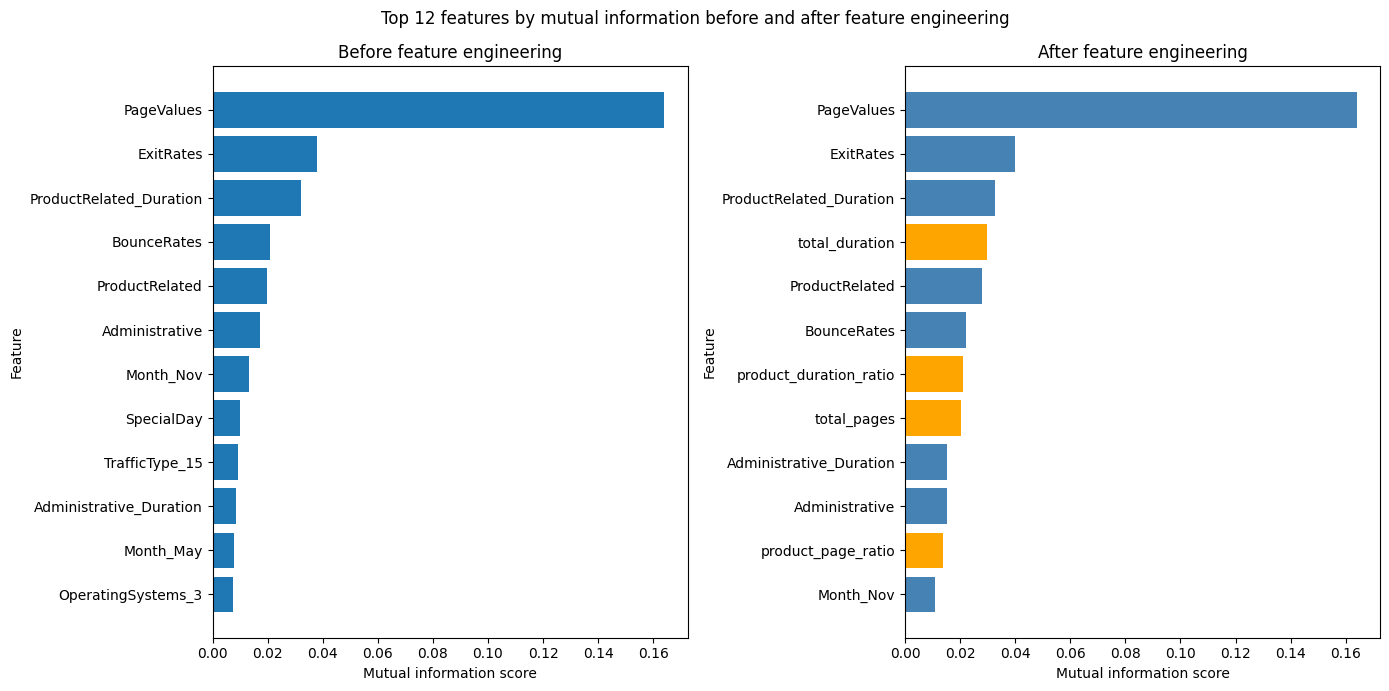

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True)

top_mi_original_features = (
    mi_scores_display_df
    .head(12)
    .sort_values("mutual_information")
)

top_mi_engineered_features = (
    mi_scores_engineered_display_df
    .head(12)
    .sort_values("mutual_information")
)

axes[0].barh(
    top_mi_original_features["feature"],
    top_mi_original_features["mutual_information"]
)
axes[0].set_title("Before feature engineering")
axes[0].set_xlabel("Mutual information score")
axes[0].set_ylabel("Feature")

engineered_colours = [
    "orange" if feature in engineered_feature_names else "steelblue"
    for feature in top_mi_engineered_features["feature"]
]

axes[1].barh(
    top_mi_engineered_features["feature"],
    top_mi_engineered_features["mutual_information"],
    color=engineered_colours
)
axes[1].set_title("After feature engineering")
axes[1].set_xlabel("Mutual information score")
axes[1].set_ylabel("Feature")

plt.suptitle("Top 12 features by mutual information before and after feature engineering")
plt.tight_layout()
plt.show()

`PageValues` still leads at `0.164`, with `ExitRates` next at `0.040` and `ProductRelated_Duration` at `0.033`. All four engineered features enter the top twelve: `total_duration` at `0.030`, `product_duration_ratio` at `0.021`, `total_pages` at `0.020` and `product_page_ratio` at `0.014`.

The engineered features carry individual signal, but mutual information scores each feature on its own. The model-level value is tested next.

### Baseline modelling with engineered features

In [120]:
engineered_baseline_results = []
engineered_trained_pipelines = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", clone(preprocessor_engineered)),
        ("model", clone(model))
    ])

    pipeline.fit(X_train_engineered, y_train_engineered)

    results, y_pred, cm = evaluate_model(
        model_name,
        pipeline,
        X_test_engineered,
        y_test_engineered
    )

    engineered_baseline_results.append(results)
    engineered_trained_pipelines[model_name] = pipeline

engineered_baseline_results_df = pd.DataFrame(engineered_baseline_results)
engineered_baseline_results_df.sort_values(by="f1", ascending=False)


Logistic Regression
Confusion matrix:
[[2010   49]
 [ 225  157]]

Classification report:
              precision    recall  f1-score   support

       False       0.90      0.98      0.94      2059
        True       0.76      0.41      0.53       382

    accuracy                           0.89      2441
   macro avg       0.83      0.69      0.74      2441
weighted avg       0.88      0.89      0.87      2441


Decision Tree
Confusion matrix:
[[1880  179]
 [ 157  225]]

Classification report:
              precision    recall  f1-score   support

       False       0.92      0.91      0.92      2059
        True       0.56      0.59      0.57       382

    accuracy                           0.86      2441
   macro avg       0.74      0.75      0.75      2441
weighted avg       0.87      0.86      0.86      2441


Random Forest
Confusion matrix:
[[1998   61]
 [ 183  199]]

Classification report:
              precision    recall  f1-score   support

       False       0.92      0.97

/Users/garyzolty/Desktop/University/AML/aml-online-shoppers/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,model,accuracy,precision,recall,f1
5,Gradient Boosting,0.901680,0.712575,0.623037,0.664804
6,Hist Gradient Boosting,0.898812,0.702703,0.612565,0.654545
2,Random Forest,0.900041,0.765385,0.520942,0.619938
4,Support Vector Machine,0.895535,0.745174,0.505236,0.602184
7,MLPClassifier,0.872184,0.598870,0.554974,0.576087
1,Decision Tree,0.862351,0.556931,0.589005,0.572519
0,Logistic Regression,0.887751,0.762136,0.410995,0.534014
3,K-Nearest Neighbours,0.868497,0.624490,0.400524,0.488038


The engineered baseline keeps the same pattern: `Gradient Boosting` leads at F1 `0.665`, followed by `Hist Gradient Boosting` at `0.655`. `Random Forest` remains more precision-leaning, with precision `0.765` but recall `0.521`. This screening selects which engineered models to tune rather than assuming the new features help.

### Tuning engineered-feature models

`Gradient Boosting`, `Hist Gradient Boosting` and `Random Forest` are the top three engineered baselines by F1. The other models are not tuned here because their engineered baselines sit lower.

In [91]:
engineered_tuned_results = []
engineered_tuned_models = {}

### Gradient Boosting: strongest engineered baseline by F1.

In [121]:
gb_engineered_pipeline = Pipeline(steps=[
    ("preprocessor",  clone(preprocessor_engineered)),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])
gb_engineered_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__min_samples_leaf": [1, 2]
}
gb_engineered_search = RandomizedSearchCV(
    gb_engineered_pipeline,
    param_distributions=gb_engineered_param_grid,
    n_iter=8,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
gb_engineered_search.fit(X_train_engineered, y_train_engineered)
gb_engineered_best_model = gb_engineered_search.best_estimator_

gb_engineered_results, gb_engineered_pred, gb_engineered_confusion = evaluate_model(
    "Tuned Gradient Boosting engineered",
    gb_engineered_best_model,
    X_test_engineered,
    y_test_engineered
)
engineered_tuned_results.append(gb_engineered_results)
engineered_tuned_models["Tuned Gradient Boosting engineered"] = gb_engineered_best_model
print(gb_engineered_search.best_params_, gb_engineered_search.best_score_)


Tuned Gradient Boosting engineered
Confusion matrix:
[[1965   94]
 [ 139  243]]

Classification report:
              precision    recall  f1-score   support

       False       0.93      0.95      0.94      2059
        True       0.72      0.64      0.68       382

    accuracy                           0.90      2441
   macro avg       0.83      0.80      0.81      2441
weighted avg       0.90      0.90      0.90      2441

{'model__n_estimators': 100, 'model__min_samples_leaf': 1, 'model__max_depth': 2, 'model__learning_rate': 0.1} 0.6568856771143644


### Hist Gradient Boosting: close engineered baseline and strong throughout.

In [122]:
hgb_engineered_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor_engineered)),
    ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))
])
hgb_engineered_param_grid = {
    "model__max_iter": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_leaf_nodes": [15, 31],
    "model__l2_regularization": [0, 0.001]
}
hgb_engineered_search = RandomizedSearchCV(
    hgb_engineered_pipeline,
    param_distributions=hgb_engineered_param_grid,
    n_iter=8,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
hgb_engineered_search.fit(X_train_engineered, y_train_engineered)
hgb_engineered_best_model = hgb_engineered_search.best_estimator_

hgb_engineered_results, hgb_engineered_pred, hgb_engineered_confusion = evaluate_model(
    "Tuned Hist Gradient Boosting engineered",
    hgb_engineered_best_model,
    X_test_engineered,
    y_test_engineered
)

engineered_tuned_results.append(hgb_engineered_results)
engineered_tuned_models["Tuned Hist Gradient Boosting engineered"] = hgb_engineered_best_model
print(hgb_engineered_search.best_params_, hgb_engineered_search.best_score_)


Tuned Hist Gradient Boosting engineered
Confusion matrix:
[[1964   95]
 [ 145  237]]

Classification report:
              precision    recall  f1-score   support

       False       0.93      0.95      0.94      2059
        True       0.71      0.62      0.66       382

    accuracy                           0.90      2441
   macro avg       0.82      0.79      0.80      2441
weighted avg       0.90      0.90      0.90      2441

{'model__max_leaf_nodes': 31, 'model__max_iter': 100, 'model__learning_rate': 0.05, 'model__l2_regularization': 0} 0.6567095831580732


### Random Forest: strongest original tuned model and current benchmark to beat.

In [123]:
rf_engineered_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor_engineered)),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])
rf_engineered_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__max_features": ["sqrt", "log2"],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__class_weight": ["balanced"]
}
rf_engineered_search = RandomizedSearchCV(
    rf_engineered_pipeline,
    param_distributions=rf_engineered_param_grid,
    n_iter=10,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_engineered_search.fit(X_train_engineered, y_train_engineered)
rf_engineered_best_model = rf_engineered_search.best_estimator_

rf_engineered_results, rf_engineered_pred, rf_engineered_confusion = evaluate_model(
    "Tuned Random Forest engineered",
    rf_engineered_best_model,
    X_test_engineered,
    y_test_engineered
)

engineered_tuned_results.append(rf_engineered_results)
engineered_tuned_models["Tuned Random Forest engineered"] = rf_engineered_best_model
print(rf_engineered_search.best_params_, rf_engineered_search.best_score_)


Tuned Random Forest engineered
Confusion matrix:
[[1945  114]
 [ 133  249]]

Classification report:
              precision    recall  f1-score   support

       False       0.94      0.94      0.94      2059
        True       0.69      0.65      0.67       382

    accuracy                           0.90      2441
   macro avg       0.81      0.80      0.80      2441
weighted avg       0.90      0.90      0.90      2441

{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 20, 'model__class_weight': 'balanced'} 0.6717104073192768


In [98]:
engineered_tuned_results_df = pd.DataFrame(engineered_tuned_results)

engineered_tuned_results_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
0,Tuned Gradient Boosting engineered,0.904547,0.721068,0.636126,0.675939
2,Tuned Random Forest engineered,0.898812,0.685950,0.651832,0.668456
1,Tuned Hist Gradient Boosting engineered,0.901680,0.713855,0.620419,0.663866


Within the engineered cycle, the three models are near-identical, with F1-scores between `0.664` and `0.676`. `Tuned Gradient Boosting engineered` is highest at F1 `0.676`, with precision `0.721` and recall `0.636`. `Tuned Gradient Boosting engineered` matches `Tuned Gradient Boosting` on the original features almost exactly, with only a one session difference in the confusion matrix. 

The engineered features contain useful summaries of session behaviour, but they do not particularly improve performance. The final comparison therefore carries forward both the strongest original-feature and the highest scoring engineered-feature contenders, as opposed to treating feature engineering as an automatic gain.

## Final contender comparison

This section compares the strongest results from the main modelling stages: baseline models, tuned models using the original features, and tuned models using the engineered features.

In [99]:
baseline_comparison_df = baseline_results_df.copy()
original_tuned_comparison_df = tuned_results_df.copy()
engineered_tuned_comparison_df = engineered_tuned_results_df.copy()

baseline_comparison_df["stage"] = "Baseline"
baseline_comparison_df["feature_set"] = "Original features"

original_tuned_comparison_df["stage"] = "Tuned"
original_tuned_comparison_df["feature_set"] = "Original features"

engineered_tuned_comparison_df["stage"] = "Tuned"
engineered_tuned_comparison_df["feature_set"] = "Engineered features"

final_comparison_df = pd.concat(
    [
        baseline_comparison_df,
        original_tuned_comparison_df,
        engineered_tuned_comparison_df
    ],
    ignore_index=True
)

final_comparison_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1,stage,feature_set
12,Tuned Random Forest,0.898402,0.668342,0.696335,0.682051,Tuned,Original features
14,Tuned Gradient Boosting engineered,0.904547,0.721068,0.636126,0.675939,Tuned,Engineered features
8,Tuned Gradient Boosting,0.904138,0.718935,0.636126,0.675000,Tuned,Original features
6,Hist Gradient Boosting,0.904957,0.727273,0.628272,0.674157,Baseline,Original features
16,Tuned Random Forest engineered,0.898812,0.685950,0.651832,0.668456,Tuned,Engineered features
9,Tuned Hist Gradient Boosting,0.902909,0.719033,0.623037,0.667602,Tuned,Original features
5,Gradient Boosting,0.901680,0.708824,0.630890,0.667590,Baseline,Original features
15,Tuned Hist Gradient Boosting engineered,0.901680,0.713855,0.620419,0.663866,Tuned,Engineered features
10,Tuned Support Vector Machine,0.872184,0.567050,0.774869,0.654867,Tuned,Original features
11,Tuned Logistic Regression,0.872593,0.569745,0.759162,0.650954,Tuned,Original features


The full comparison shows the strongest results came from tuned tree-based ensembles. `Random Forest` on the original features has the highest test recall and F1-score. `Gradient Boosting` on the engineered features has the highest precision and the smallest gap between its tuned baseline and test results. These two models represent the strongest candidates from different families and are taken forward as finalists.

### Accuracy and interpretability trade-off

`Logistic Regression` is the most interpretable model because its predictions are based on a simpler linear relationship between the processed features and the target. However, it does not capture the non-linear browsing patterns as effectively as the tree-based ensembles.

The tree-based models are less transparent, but they achieve stronger predictive performance and can still be interpreted using permutation importance. For this project, the ensembles are preferred because the aim is to identify useful conversion patterns from historical sessions, while permutation importance provides a practical way to explain which features drive the predictions.

In [100]:
final_contender_names = [
    "Tuned Random Forest",
    "Tuned Random Forest engineered",
    "Tuned Gradient Boosting engineered"
]

top_contenders = final_comparison_df[
    final_comparison_df["model"].isin(final_contender_names)
].copy()

top_contenders.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1,stage,feature_set
12,Tuned Random Forest,0.898402,0.668342,0.696335,0.682051,Tuned,Original features
14,Tuned Gradient Boosting engineered,0.904547,0.721068,0.636126,0.675939,Tuned,Engineered features
16,Tuned Random Forest engineered,0.898812,0.685950,0.651832,0.668456,Tuned,Engineered features


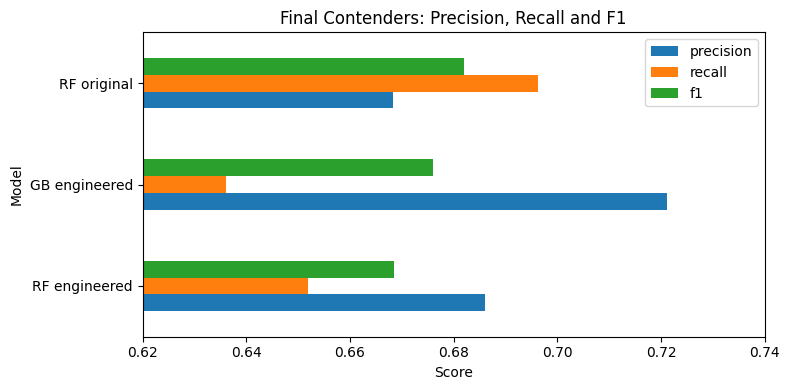

In [101]:
top_contenders_plot = top_contenders.copy()

top_contenders_plot["model"] = top_contenders_plot["model"].replace({
    "Tuned Random Forest": "RF original",
    "Tuned Random Forest engineered": "RF engineered",
    "Tuned Gradient Boosting engineered": "GB engineered"
})

top_contenders_plot = top_contenders_plot.sort_values(by="f1", ascending=True)

top_contenders_plot.plot(
    x="model",
    y=["precision", "recall", "f1"],
    kind="barh",
    figsize=(8, 4)
)

# zoom in on the final-contender range so the trade-off is easier to compare
plt.xlim(0.62, 0.74)
plt.xlabel("Score")
plt.ylabel("Model")
plt.title("Final Contenders: Precision, Recall and F1")
plt.tight_layout()
plt.show()

The chart confirms that the two finalists make different trade-offs. `RF original` has stronger recall and F1-score. `GB engineered` has stronger precision. Within the engineered feature set, GB outperforms `RF engineered` on both precision and F1-score, which means the engineered feature set did not improve Random Forest performance over its original-feature version. The engineered features appear to benefit GB more than RF.

## Confusion matrix summary for final contenders

In [102]:
rf_original_pred = rf_search.predict(X_test_original)
rf_engineered_pred = rf_engineered_search.best_estimator_.predict(X_test_engineered)
gb_engineered_pred = gb_engineered_best_model.predict(X_test_engineered)

rf_confusion_matrix = confusion_matrix(y_test_original, rf_original_pred)
rf_engineered_confusion_matrix = confusion_matrix(y_test_engineered, rf_engineered_pred)
gb_engineered_confusion_matrix = confusion_matrix(y_test_engineered, gb_engineered_pred)

print("Final contender 1: Tuned Random Forest using original features")
print(rf_confusion_matrix)

print("\nFinal contender 2: Tuned Random Forest using engineered features")
print(rf_engineered_confusion_matrix)

print("\nFinal contender 3: Tuned Gradient Boosting using engineered features")
print(gb_engineered_confusion_matrix)

Final contender 1: Tuned Random Forest using original features
[[1927  132]
 [ 116  266]]

Final contender 2: Tuned Random Forest using engineered features
[[1945  114]
 [ 133  249]]

Final contender 3: Tuned Gradient Boosting using engineered features
[[1965   94]
 [ 139  243]]


In [103]:
def summarise_confusion_matrix(model_name, cm):
    tn, fp, fn, tp = cm.ravel()
    
    return {
        "model": model_name,
        "true_purchases_found": tp,
        "missed_purchases": fn,
        "false_purchase_predictions": fp,
        "correct_non_purchases": tn
    }


confusion_summary_df = pd.DataFrame([
    summarise_confusion_matrix("RF original", rf_confusion_matrix),
    summarise_confusion_matrix("RF engineered", rf_engineered_confusion_matrix),
    summarise_confusion_matrix("GB engineered", gb_engineered_confusion_matrix)
])

confusion_summary_df

,model,true_purchases_found,missed_purchases,false_purchase_predictions,correct_non_purchases
0,RF original,266,116,132,1927
1,RF engineered,249,133,114,1945
2,GB engineered,243,139,94,1965


The confusion matrix summary shows the practical difference between the final contenders.

`RF original` finds the most purchase sessions, but it also makes the highest number of false purchase predictions.

`RF engineered` is slightly more cautious than `RF original`, with fewer false purchase predictions but more missed purchases.

`GB engineered` is the most selective model, with the fewest false purchase predictions. However, it misses more purchase sessions than both Random Forest models. 

In an e-commerce context, false negatives represent missed remarketing opportunities, sessions that ended in a purchase but were not flagged. False positives represent wasted marketing spend, sessions incorrectly targeted as likely purchasers. RF's higher recall makes it preferable when the cost of a missed conversion is high. GB's higher precision makes it preferable when marketing budget efficiency is the priority.

## Repeated cross-validation check

### Additional Random Forest regularisation check

As seen after this code snippet, repeated cross-validation results show that `Tuned Random Forest` has the strongest recall and F1-score, but also the largest train-test F1 gap. A more regularised Random Forest is therefore tested as a focused robustness check, to check whether the overfitting gap can be reduced without losing too much recall or F1-score.

In [104]:
rf_regularised_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor_original)),
    ("model", RandomForestClassifier(
    n_estimators=200,
    max_depth=8,              # Drastically reduce from deep/unlimited splits
    min_samples_leaf=5,       # Prevent memorization of isolated sessions
    max_features='sqrt',
    class_weight='balanced',  # Handle class skew directly within the trees
    random_state=42
    ))
])

rf_regularised_pipeline.fit(X_train_original, y_train_original)

rf_regularised_results, rf_regularised_pred, rf_regularised_confusion = evaluate_model(
    "Regularised Random Forest",
    rf_regularised_pipeline,
    X_test_original,
    y_test_original
)

rf_regularised_results


Regularised Random Forest
Confusion matrix:
[[1795  264]
 [  66  316]]

Classification report:
              precision    recall  f1-score   support

       False       0.96      0.87      0.92      2059
        True       0.54      0.83      0.66       382

    accuracy                           0.86      2441
   macro avg       0.75      0.85      0.79      2441
weighted avg       0.90      0.86      0.88      2441



{'model': 'Regularised Random Forest',
 'accuracy': 0.8648095043015158,
 'precision': 0.5448275862068965,
 'recall': 0.8272251308900523,
 'f1': 0.656964656964657}

In [105]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

# Repeated stratified CV gives a more robust comparison than relying on one split.
# Stratification is important because the target class is imbalanced.
repeated_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=RANDOM_STATE
)

final_cv_models = {
    "Tuned Random Forest original": rf_search.best_estimator_,
    "Tuned Random Forest engineered": rf_engineered_search.best_estimator_,
    "Regularised Random Forest original": rf_regularised_pipeline,
    "Tuned Gradient Boosting engineered": gb_engineered_best_model
}

final_cv_data = {
    "Tuned Random Forest original": (X_train_original, y_train_original),
    "Tuned Random Forest engineered": (X_train_engineered, y_train_engineered),
    "Regularised Random Forest original": (X_train_original, y_train_original),
    "Tuned Gradient Boosting engineered": (X_train_engineered, y_train_engineered)
}

scoring = {
    "balanced_accuracy": "balanced_accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "average_precision": "average_precision"
}

final_cv_results = []

for model_name, model in final_cv_models.items():
    X_cv, y_cv = final_cv_data[model_name]

    scores = cross_validate(
        model,
        X_cv,
        y_cv,
        scoring=scoring,
        cv=repeated_cv,
        n_jobs=-1,
        return_train_score=True
    )

    f1_scores = scores["test_f1"]
    
    final_cv_results.append({
        "model": model_name,
        "balanced_accuracy_mean": scores["test_balanced_accuracy"].mean(),
        "precision_mean": scores["test_precision"].mean(),
        "recall_mean": scores["test_recall"].mean(),
        "f1_mean": f1_scores.mean(),
        "f1_std": f1_scores.std(),
        "average_precision_mean": scores["test_average_precision"].mean(),
        "train_f1_mean": scores["train_f1"].mean(),
        "test_train_f1_gap": scores["train_f1"].mean() - f1_scores.mean()
    })

final_cv_results_df = (
    pd.DataFrame(final_cv_results)
    .sort_values(by="f1_mean", ascending=False)
    .round(3)
    .reset_index(drop=True)
)

final_cv_results_df

,model,balanced_accuracy_mean,precision_mean,recall_mean,f1_mean,f1_std,average_precision_mean,train_f1_mean,test_train_f1_gap
0,Tuned Random Forest original,0.817,0.661,0.701,0.679,0.012,0.739,0.919,0.240
1,Tuned Random Forest engineered,0.805,0.688,0.666,0.676,0.016,0.732,0.952,0.276
2,Tuned Gradient Boosting engineered,0.778,0.718,0.600,0.654,0.018,0.739,0.688,0.034
3,Regularised Random Forest original,0.847,0.539,0.825,0.651,0.012,0.696,0.683,0.031


The regularised `Random Forest` was tested to check whether the larger train-test F1 gap in the tuned Random Forest could be reduced. Stricter tree settings reduced the gap substantially, from `0.240` to `0.031`.

However, the change also shifted the model behaviour. The regularised model achieved the highest recall, but its precision was much lower than the tuned Random Forest and engineered Gradient Boosting models. This means it is useful as a robustness check, but not a clear replacement for the main model. It shows that the overfitting issue can be reduced, but the resulting model becomes too broad for a stable audit tool.

## Final model choice

The final comparison focuses on two strongest but different options:

- `Tuned Random Forest` using the original features gives the strongest F1-score and recall. It is better at finding purchase sessions, but it also produces more false positives and shows a larger train-test F1 gap.
- `Tuned Gradient Boosting` using the engineered features gives slightly lower F1-score and recall, but higher precision, fewer false positives and a smaller train-test F1 gap.

For this project, the selected main model is `Tuned Gradient Boosting` with engineered features. This fits the aim of an offline conversion-audit tool, where the model should identify reliable purchase patterns rather than simply flag as many possible purchase sessions as possible.

`Tuned Random Forest` remains the stronger alternative if the business priority is recall, meaning the aim is to capture as many purchase sessions as possible even if more non-purchase sessions are incorrectly flagged.

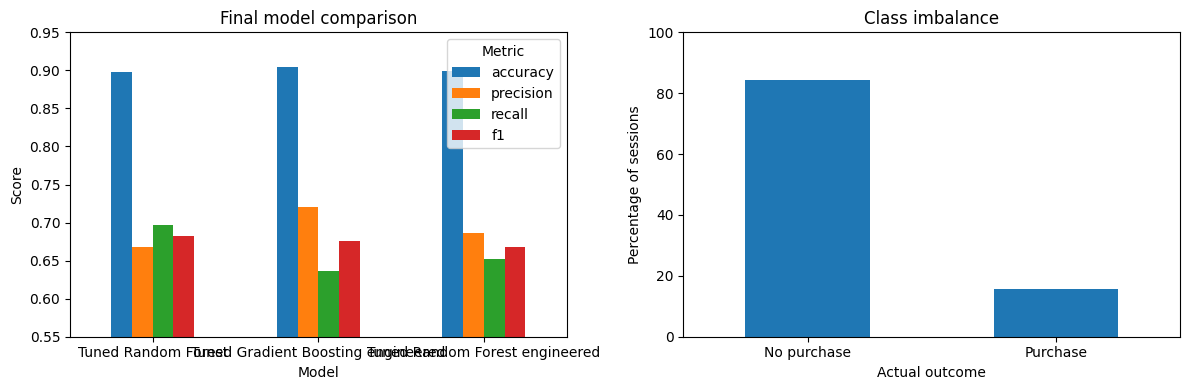

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

final_model_choice_df = top_contenders[
    ["model", "feature_set", "accuracy", "precision", "recall", "f1"]
].copy()

final_model_plot_df = final_model_choice_df.set_index("model")[
    ["accuracy", "precision", "recall", "f1"]
]

final_model_plot_df.plot(
    kind="bar",
    ax=axes[0],
    rot=0
)

axes[0].set_ylim(0.55, 0.95)
axes[0].set_ylabel("Score")
axes[0].set_xlabel("Model")
axes[0].set_title("Final model comparison")
axes[0].legend(title="Metric")

class_balance = y.value_counts(normalize=True).sort_index() * 100
class_balance.index = ["No purchase", "Purchase"]

class_balance.plot(
    kind="bar",
    ax=axes[1],
    rot=0
)

axes[1].set_ylim(0, 100)
axes[1].set_ylabel("Percentage of sessions")
axes[1].set_xlabel("Actual outcome")
axes[1].set_title("Class imbalance")

plt.tight_layout()
plt.show()

In [107]:
final_model_choice_df = top_contenders[
    ["model", "feature_set", "accuracy", "precision", "recall", "f1"]
].copy()

rf_tn, rf_fp, rf_fn, rf_tp = rf_confusion_matrix.ravel()
gb_tn, gb_fp, gb_fn, gb_tp = gb_engineered_confusion_matrix.ravel()

final_model_choice_df["false_positives"] = final_model_choice_df["model"].map({
    "Tuned Random Forest": rf_fp,
    "Tuned Gradient Boosting engineered": gb_fp
})

final_model_choice_df["missed_purchases"] = final_model_choice_df["model"].map({
    "Tuned Random Forest": rf_fn,
    "Tuned Gradient Boosting engineered": gb_fn
})

final_model_choice_df = final_model_choice_df.sort_values(
    by="f1",
    ascending=False
)

final_model_choice_df.style.format({
    "accuracy": "{:.3f}",
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}"
}).highlight_max(
    subset=["accuracy", "precision", "recall", "f1"],
    color="lightblue"
)

,model,feature_set,accuracy,precision,recall,f1,false_positives,missed_purchases
12,Tuned Random Forest,Original features,0.898,0.668,0.696,0.682,132.000000,116.000000
14,Tuned Gradient Boosting engineered,Engineered features,0.905,0.721,0.636,0.676,94.000000,139.000000
16,Tuned Random Forest engineered,Engineered features,0.899,0.686,0.652,0.668,nan,nan


Among the final contenders, `GB engineered` has the highest precision and the fewest false positives. In the repeated cross-validation check, it also has a much smaller train-test F1 gap than the tuned `Random Forest` models.

## Permutation importance

In [108]:
# Permutation importance for the selected main model:
# Tuned Gradient Boosting with engineered features

gb_perm_importance = permutation_importance(
    gb_engineered_best_model,
    X_test_engineered,
    y_test_engineered,
    scoring="f1",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

gb_perm_importance_df = (
    pd.DataFrame({
        "feature": X_test_engineered.columns,
        "importance_mean": gb_perm_importance.importances_mean,
        "importance_std": gb_perm_importance.importances_std
    })
    .sort_values(by="importance_mean", ascending=False)
    .reset_index(drop=True)
)

gb_perm_importance_df.head(15)

,feature,importance_mean,importance_std
0,PageValues,0.502893,0.014679
1,Month,0.041324,0.009141
2,ExitRates,0.021838,0.006654
3,BounceRates,0.013687,0.005345
4,ProductRelated_Duration,0.008047,0.003027
5,Administrative,0.007200,0.006096
6,ProductRelated,0.005531,0.001957
7,total_pages,0.003216,0.003614
8,product_duration_ratio,0.002622,0.003239
9,total_duration,0.002318,0.003661


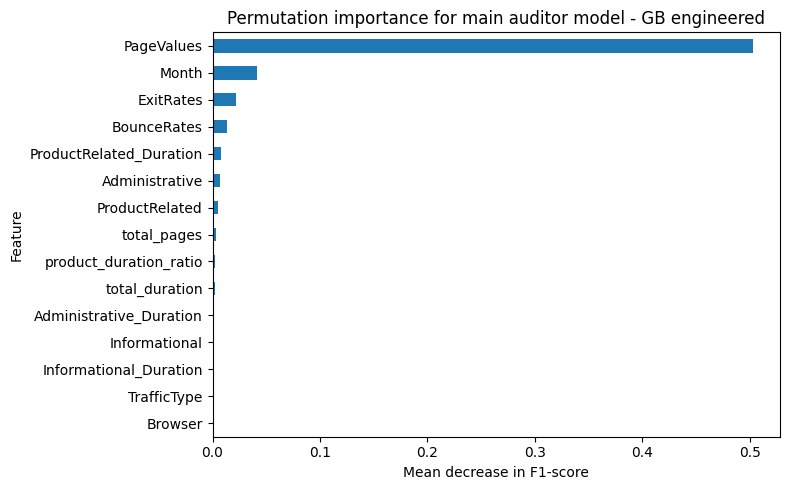

In [109]:
# Plot the most important features for the selected main model

top_gb_perm_importance = (
    gb_perm_importance_df
    .head(15)
    .sort_values(by="importance_mean", ascending=True)
)

top_gb_perm_importance.plot(
    x="feature",
    y="importance_mean",
    kind="barh",
    figsize=(8, 5),
    legend=False
)

plt.xlabel("Mean decrease in F1-score")
plt.ylabel("Feature")
plt.title("Permutation importance for main auditor model - GB engineered")
plt.tight_layout()
plt.show()

In [110]:
# Permutation importance for the recall-focused comparison model:
# Tuned Random Forest with original features

rf_perm_importance = permutation_importance(
    rf_search.best_estimator_,
    X_test_original,
    y_test_original,
    scoring="f1",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_perm_importance_df = (
    pd.DataFrame({
        "feature": X_test_original.columns,
        "importance_mean": rf_perm_importance.importances_mean,
        "importance_std": rf_perm_importance.importances_std
    })
    .sort_values(by="importance_mean", ascending=False)
    .reset_index(drop=True)
)

rf_perm_importance_df.head(15)

,feature,importance_mean,importance_std
0,PageValues,0.472413,0.013380
1,ExitRates,0.043457,0.018587
2,Month,0.020181,0.008444
3,ProductRelated,0.013553,0.003084
4,ProductRelated_Duration,0.009030,0.008174
5,TrafficType,0.007603,0.002879
6,Weekend,0.004966,0.003204
7,BounceRates,0.004545,0.008105
8,Informational,0.004149,0.002716
9,Administrative,0.002998,0.004073


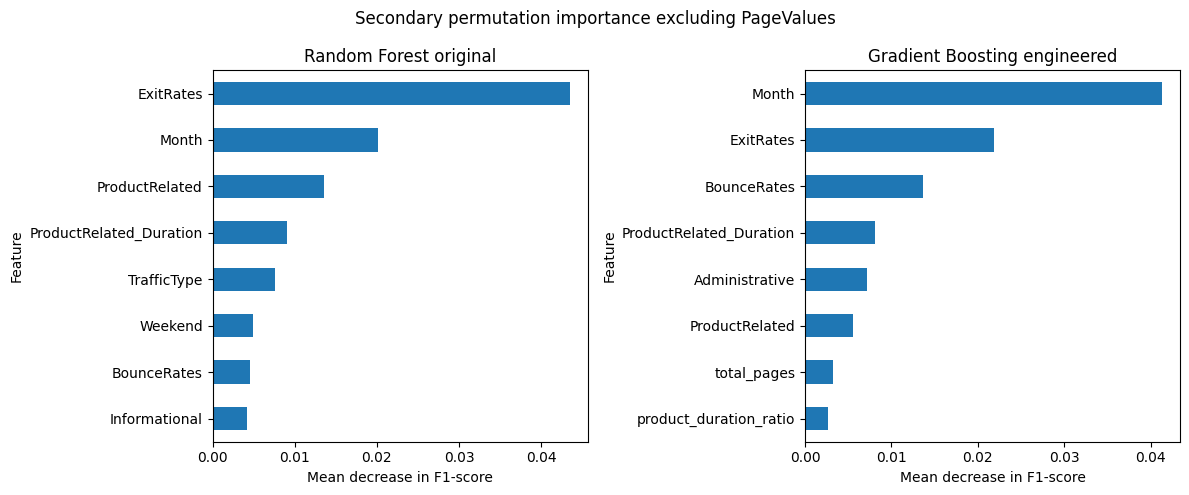

In [111]:
# Compare secondary feature importance after removing PageValues.
# This helps show what each model uses once the dominant post-session signal is excluded.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

rf_secondary_importance = (
    rf_perm_importance_df[
        rf_perm_importance_df["feature"] != "PageValues"
    ]
    .head(8)
    .sort_values(by="importance_mean", ascending=True)
)

gb_secondary_importance = (
    gb_perm_importance_df[
        gb_perm_importance_df["feature"] != "PageValues"
    ]
    .head(8)
    .sort_values(by="importance_mean", ascending=True)
)

rf_secondary_importance.plot(
    x="feature",
    y="importance_mean",
    kind="barh",
    legend=False,
    ax=axes[0]
)

gb_secondary_importance.plot(
    x="feature",
    y="importance_mean",
    kind="barh",
    legend=False,
    ax=axes[1]
)

axes[0].set_title("Random Forest original")
axes[0].set_xlabel("Mean decrease in F1-score")
axes[0].set_ylabel("Feature")

axes[1].set_title("Gradient Boosting engineered")
axes[1].set_xlabel("Mean decrease in F1-score")
axes[1].set_ylabel("Feature")

plt.suptitle("Secondary permutation importance excluding PageValues")
plt.tight_layout()
plt.show()

After removing `PageValues`, the two finalists use different secondary signals. `Random Forest` relies most on `ExitRates`, followed by browsing-volume features such as `ProductRelated` and `ProductRelated_Duration`. `Gradient Boosting` relies most on `Month`, then `ExitRates`, `BounceRates` and product-browsing duration.

For the offline conversion-audit use case, this is useful because it shows the model is capturing interpretable post-session patterns, including traffic quality, seasonal timing and product engagement. These findings should not be treated as causal business rules, because permutation importance shows model dependence rather than direct cause and effect.

Permutation importance was used to check which features most affected each finalist's F1-score on the held-out test set. This gives a post-training interpretation of the models by measuring how much performance drops when each feature is randomly shuffled.

Both finalists rely strongly on `PageValues`, so the main predictive signal is not specific to one algorithm. The secondary features differ more: the Random Forest places more weight on traffic-quality variables such as `ExitRates`, while the Gradient Boosting model places more weight on timing and engineered browsing-behaviour features.

`PageValues` should be interpreted carefully. It is useful for this project because the model is framed as a post-session conversion-audit tool. It would not be suitable for an early-session intervention model unless a separate experiment showed that the feature was available before checkout.

## Final model choice

Two models are proposed as the strongest options for different operational purposes. This reflects the precision-recall trade-off shown in the final contender table, confusion matrix summary and repeated cross-validation results.

`Tuned Gradient Boosting engineered` is selected as the main auditor model. It has slightly lower F1-score than `Tuned Random Forest original`, but it gives higher precision, fewer false positives and a much smaller train-test F1 gap in the repeated cross-validation check.

`Tuned Random Forest original` is retained as a high-recall comparison model. It identifies more purchase sessions, but its larger train-test F1 gap makes it less suitable as the main model for stable business insight. The regularised Random Forest check shows that the gap can be reduced, but this shifts the model towards very high recall and lower precision, so it is not a clean replacement.

Main selected model: Tuned Gradient Boosting engineered
Comparison model: Tuned Random Forest original

Why?

Random Forest original has the highest test F1 and recall.
Gradient Boosting engineered has higher precision, fewer false positives and a much smaller train-test F1 gap.
For an offline audit tool, selectivity and stability are more important than simply finding the maximum number of purchase sessions.
Must acknowledge that RF is still better for recall-focused use cases.

Gradient Boosting engineered is not exactly “best overall”, numerically, RF has the best F1.

## Limitations and possible improvements

The final model should be interpreted as session-level revenue prediction, not early-session prediction. 

Future work could tune the decision threshold for a specific business objective, apply probability calibration if reliable purchase probabilities are required, and validate the model on newer e-commerce sessions or an external dataset. A separate early-intervention version could also test performance without `PageValues`.

Several limitations should be noted. First, `PageValues` is a Google Analytics metric that may only be available after meaningful browsing activity or after the session has completed. This means the final models are better understood as post-session revenue prediction models rather than real-time early-intervention models. A live intervention version would need to be tested without `PageValues`.

Second, the dataset does not include a timestamp. This means temporal generalisation cannot be tested, and the train-test split may mix sessions from different time periods. If user behaviour changes over time, the test results may be more optimistic than performance on future sessions.

Third, `Tuned Random Forest` has a larger train-test F1 gap than `Tuned Gradient Boosting engineered`, which suggests a higher risk of overfitting. Further tuning with stricter depth limits, larger minimum leaf sizes, or validation on a separate dataset would be needed before relying on it in deployment.

Fourth, the classification threshold was not tuned. All models use the default `0.5` threshold, even though a different threshold could improve either recall or precision depending on the business objective. A future version could use the precision-recall curve to choose a threshold for a specific campaign goal.

Finally, the engineered features added useful context but only marginal improvement. They helped the engineered `Gradient Boosting` model remain competitive, but they did not clearly improve `Random Forest` over the original feature set. This suggests that most of the predictive signal still comes from the original session variables, especially `PageValues`.


## Notebook summary

This notebook built and compared supervised classification models for predicting online purchase intention.

The workflow included data inspection, preprocessing, feature selection, baseline modelling, tuning, feature engineering, final contender comparison, permutation importance and final model selection.

Eight candidate classifiers were evaluated across baseline and tuned stages using a stratified `80/20` train-test split. Tuning used `RandomizedSearchCV` with 5-fold cross-validation and F1-score as the main scoring metric, because the purchase class is much smaller than the non-purchase class.

Feature engineering added four session-level variables: `total_pages`, `total_duration`, `product_page_ratio` and `product_duration_ratio`. These features added some useful context, but they did not substantially improve performance over the original feature set.

`PageValues` was the dominant predictor across the feature analysis, diagnostic experiment and permutation importance results. This supports the final scope of the notebook as a post-session purchase prediction task rather than a real-time intervention system.

The final results show two useful model options. `Tuned Gradient Boosting engineered` is more stable and more selective, while `Tuned Random Forest` uses the original features and is stronger for recall-focused use cases.